# 3b - Albero Decisionale

Questo notebook implementa, ottimizza e interpreta un classificatore basato su un singolo Albero Decisionale per la previsione della variabile target `blueWins`.

Gli obiettivi principali sono:

1. addestrare un `DecisionTreeClassifier`;
2. ottimizzarne gli iperparametri tramite Grid Search con 5-Fold Cross-Validation;
3. confrontare esplicitamente i criteri di impurità Gini ed Entropia;
4. visualizzare graficamente l'albero ottimizzato;
5. estrarre le regole decisionali dalla radice alle foglie;
6. calcolare supporto e confidenza di ogni regola;
7. salvare il modello ottimizzato nella cartella `models/`.

L'addestramento utilizza esclusivamente il Training Set. Il Test Set rimane separato e non viene utilizzato durante la selezione degli iperparametri.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import _tree

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\mela\Desktop\predictLoL\predictLoL


## 1. Caricamento del Training Set

Per l'Albero Decisionale viene utilizzato il Training Set preprocessato ma non standardizzato.

Gli alberi decisionali effettuano le divisioni confrontando i valori delle singole feature con determinate soglie e non richiedono che tutte le feature siano espresse sulla stessa scala.

Utilizzare i valori nelle unità originali rende inoltre le regole estratte più facilmente interpretabili. Ad esempio, una soglia su `blueGoldDiff` può essere espressa direttamente in quantità di oro.

In [3]:
X_TRAIN_PATH = PROJECT_ROOT / "data" / "X_train.csv"
Y_TRAIN_PATH = PROJECT_ROOT / "data" / "y_train.csv"

assert X_TRAIN_PATH.exists(), f"File non trovato: {X_TRAIN_PATH}"
assert Y_TRAIN_PATH.exists(), f"File non trovato: {Y_TRAIN_PATH}"

X_train = pd.read_csv(X_TRAIN_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH)["blueWins"]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

X_train: (7903, 27)
y_train: (7903,)


In [4]:
print("Valori mancanti in X_train:", X_train.isna().sum().sum())
print("Valori mancanti in y_train:", y_train.isna().sum())

print("\ngameId presente:", "gameId" in X_train.columns)

print("\nDistribuzione target:")
print(y_train.value_counts())

Valori mancanti in X_train: 0
Valori mancanti in y_train: 0

gameId presente: False

Distribuzione target:
blueWins
0    3959
1    3944
Name: count, dtype: int64


## 2. Criteri di impurità: Gini ed Entropia

Per decidere quale feature e quale soglia utilizzare in ogni nodo, l'Albero Decisionale cerca una divisione che renda i nodi figli il più possibile "puri".

Un nodo è puro quando contiene osservazioni appartenenti prevalentemente a una sola classe.

In questa analisi vengono confrontati due criteri:

### Indice di Gini

Il Gini assume valore minimo quando il nodo contiene osservazioni appartenenti a una sola classe e aumenta quando le classi risultano maggiormente mescolate.

### Entropia

L'Entropia misura l'incertezza nella distribuzione delle classi. Anche in questo caso un valore basso indica un nodo più puro.

La Grid Search confronterà entrambi i criteri per stabilire quale produca le migliori prestazioni medie in Cross-Validation.

In [5]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [6]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_samples_split": [2, 5, 10, 20, 50]
}

In [7]:
tree_grid = GridSearchCV(
    estimator=tree_model,
    param_grid=tree_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

tree_grid.fit(X_train, y_train)

print("Grid Search completata.")

Grid Search completata.


In [8]:
print("Migliori iperparametri:")
print(tree_grid.best_params_)

print(
    f"\nMigliore accuracy media in Cross-Validation: "
    f"{tree_grid.best_score_:.4f}"
)

Migliori iperparametri:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}

Migliore accuracy media in Cross-Validation: 0.7224


In [9]:
cv_results = pd.DataFrame(tree_grid.cv_results_)

best_by_criterion = (
    cv_results
    .sort_values("mean_test_score", ascending=False)
    .groupby("param_criterion", as_index=False)
    .first()
)

best_by_criterion[
    [
        "param_criterion",
        "param_max_depth",
        "param_min_samples_split",
        "mean_train_score",
        "mean_test_score",
        "std_test_score"
    ]
]

,param_criterion,param_max_depth,param_min_samples_split,mean_train_score,mean_test_score,std_test_score
0,entropy,3,20,0.726591,0.722382,0.007337
1,gini,3,2,0.726591,0.722382,0.007337


In [10]:
best_tree = tree_grid.best_estimator_

best_tree

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

## 3. Visualizzazione dell'Albero Ottimizzato

L'albero ottimizzato viene rappresentato graficamente mediante `plot_tree`.

Per ogni nodo vengono mostrati:

- la feature utilizzata per lo split;
- la soglia scelta;
- il valore di impurità (`gini` oppure `entropy`);
- il numero di campioni presenti nel nodo;
- la distribuzione delle osservazioni tra le due classi;
- la classe predetta.

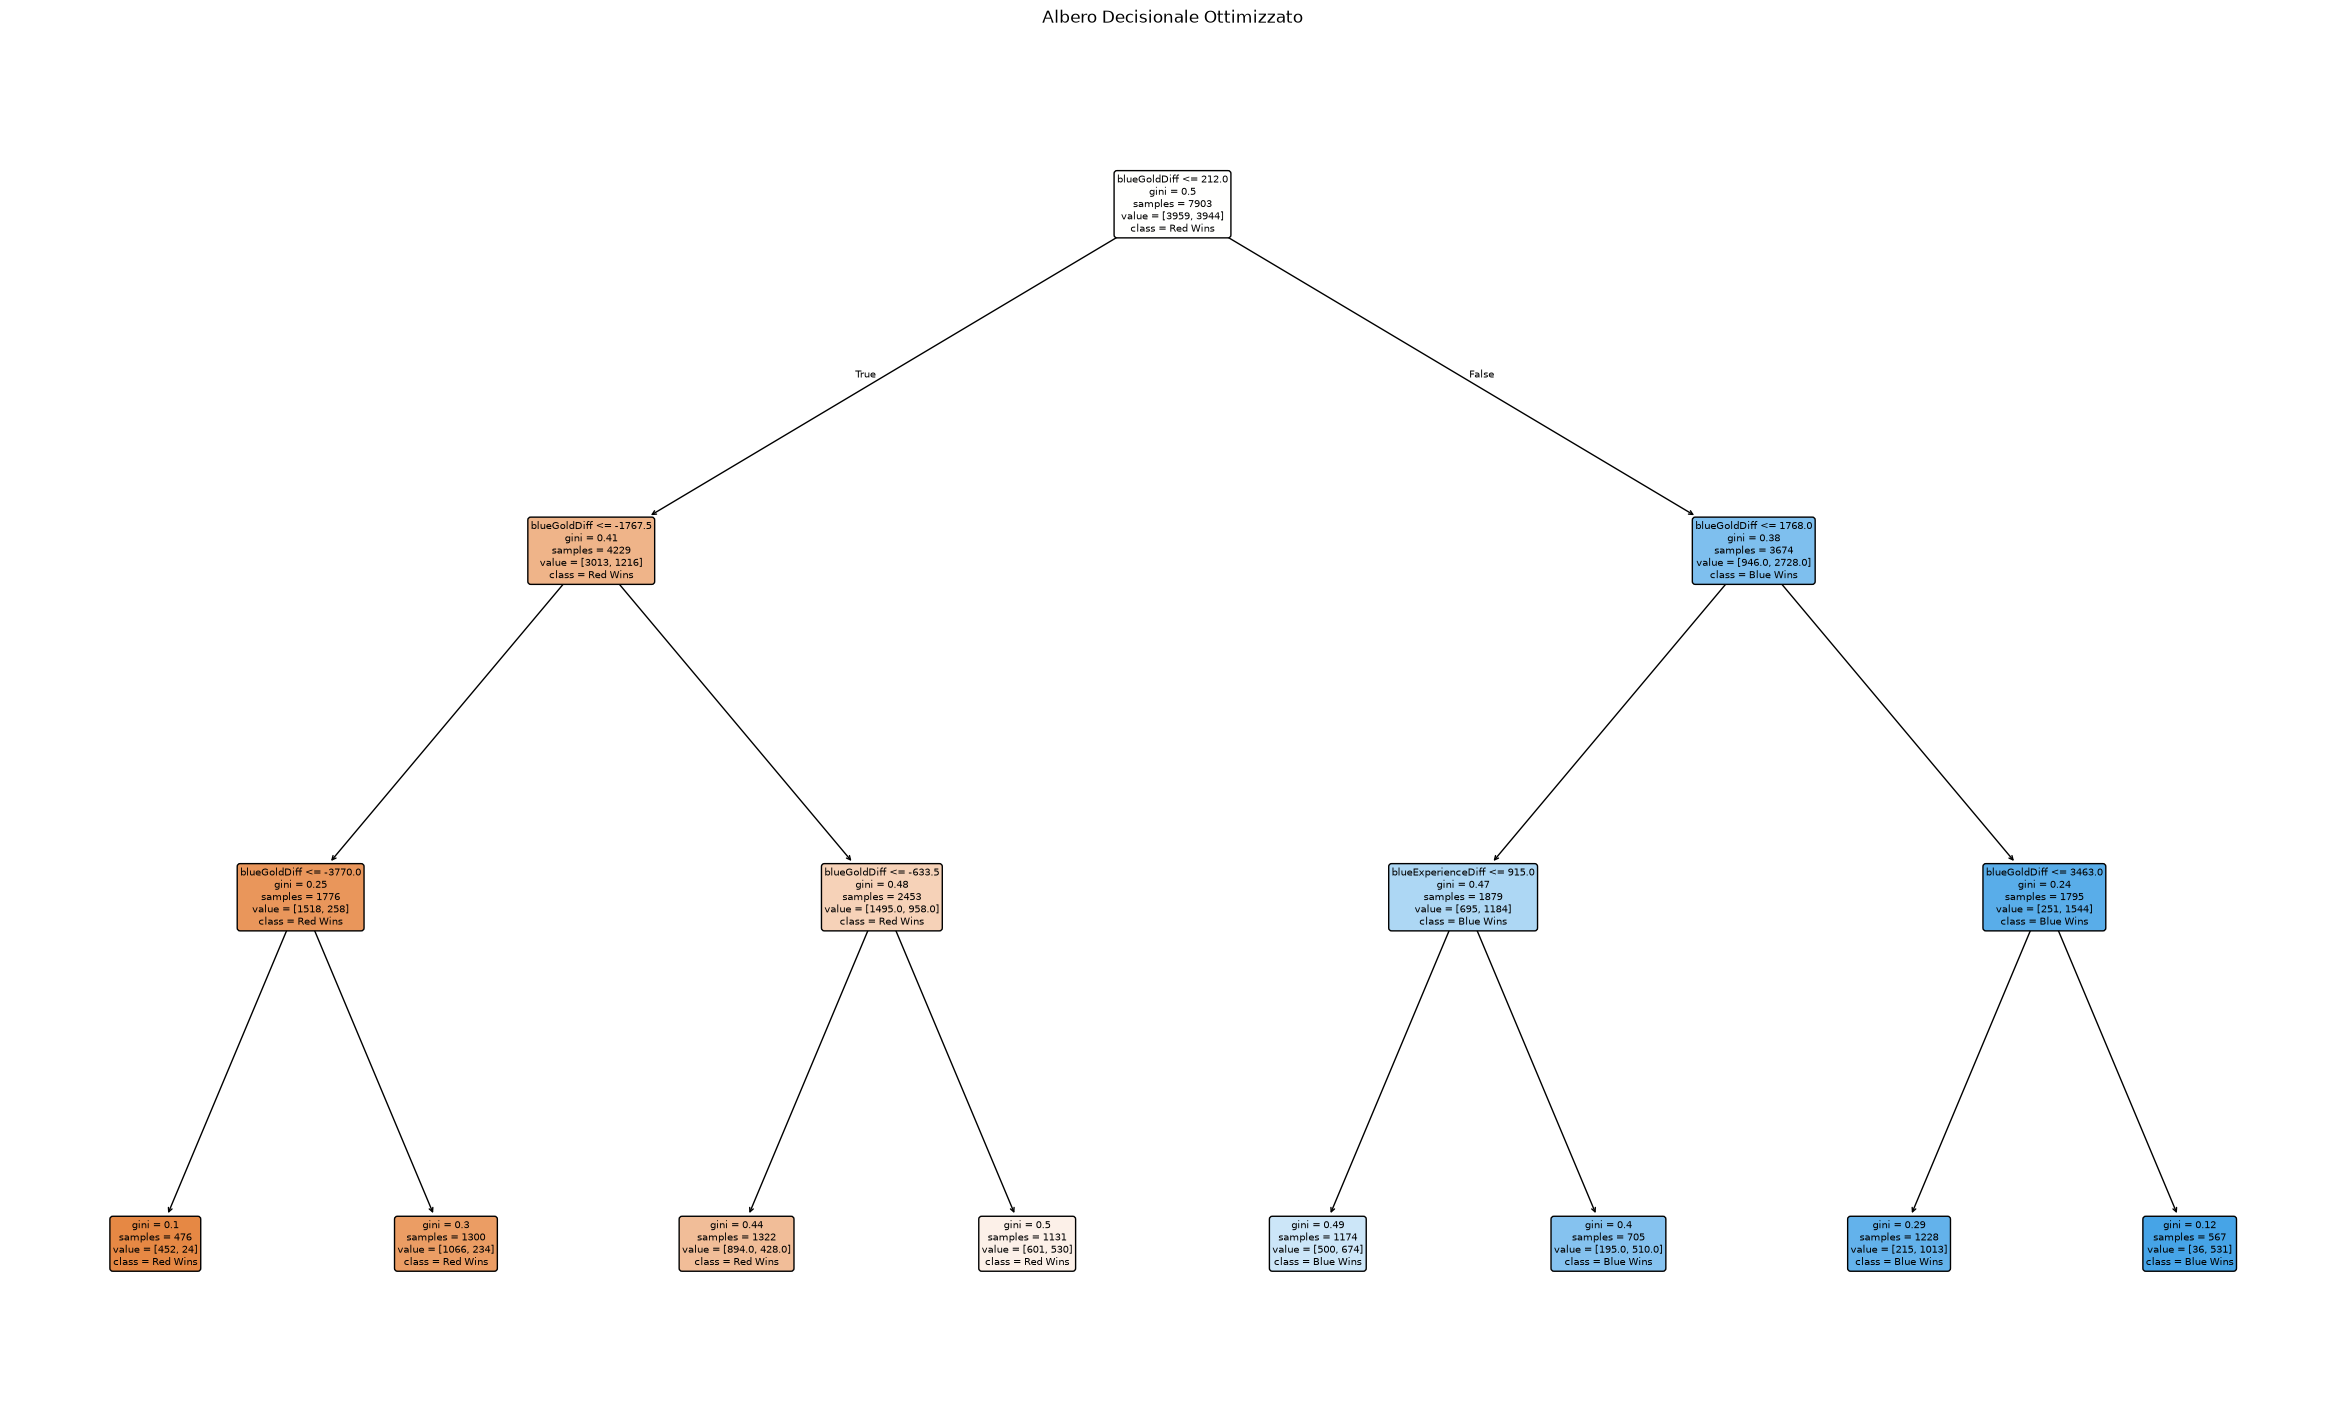

In [11]:
plt.figure(figsize=(30, 18))

plot_tree(
    best_tree,
    feature_names=X_train.columns,
    class_names=["Red Wins", "Blue Wins"],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    precision=2,
    fontsize=7
)

plt.title("Albero Decisionale Ottimizzato")

plt.show()

In [12]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
13,blueGoldDiff,0.982175
14,blueExperienceDiff,0.017825
0,blueWardsPlaced,0.000000
3,blueKills,0.000000
4,blueDeaths,0.000000
5,blueDragons,0.000000
6,blueHeralds,0.000000
7,blueTowersDestroyed,0.000000
8,blueTotalGold,0.000000
1,blueWardsDestroyed,0.000000


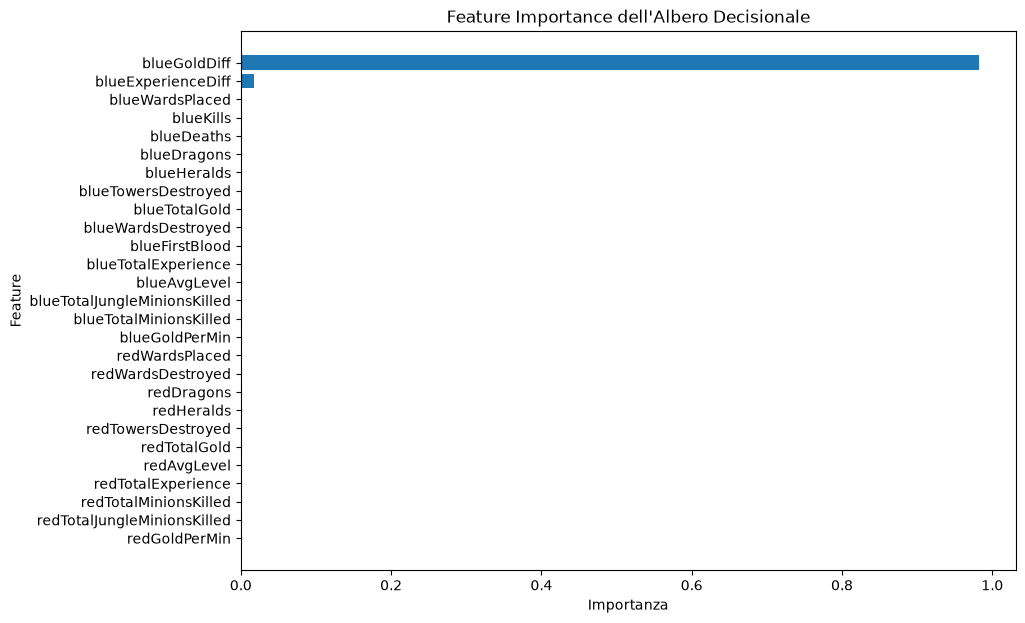

In [13]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importanza")
plt.ylabel("Feature")
plt.title("Feature Importance dell'Albero Decisionale")

plt.gca().invert_yaxis()
plt.show()

## 4. Estrazione delle Regole di Classificazione

Ogni percorso dalla radice dell'albero a una foglia può essere tradotto in una regola logica.

Per convenzione:

- il ramo sinistro rappresenta una condizione `feature <= soglia`;
- il ramo destro rappresenta una condizione `feature > soglia`.

Per ogni regola vengono calcolati:

### Supporto

Percentuale delle osservazioni del Training Set che soddisfano tutte le condizioni della regola.

### Confidenza

Tra le osservazioni che soddisfano la regola, percentuale appartenente effettivamente alla classe predetta dalla foglia.

In [14]:
def estrai_regole(modello, X, y):
    """
    Estrae tutte le regole root-to-leaf da un DecisionTreeClassifier
    e calcola supporto e confidenza sul dataset fornito.
    """

    struttura = modello.tree_
    feature_names = list(X.columns)

    regole = []

    def visita_nodo(node_id, condizioni):

        feature_index = struttura.feature[node_id]

        # Se non è una foglia
        if feature_index != _tree.TREE_UNDEFINED:

            feature_name = feature_names[feature_index]
            threshold = struttura.threshold[node_id]

            # Ramo sinistro: <= soglia
            visita_nodo(
                struttura.children_left[node_id],
                condizioni + [
                    (feature_name, "<=", threshold)
                ]
            )

            # Ramo destro: > soglia
            visita_nodo(
                struttura.children_right[node_id],
                condizioni + [
                    (feature_name, ">", threshold)
                ]
            )

        else:
            # Classe predetta dalla foglia
            predicted_class = int(
                np.argmax(struttura.value[node_id][0])
            )

            # Trova le righe che soddisfano la regola
            mask = pd.Series(
                True,
                index=X.index
            )

            for feature, operatore, threshold in condizioni:

                if operatore == "<=":
                    mask &= X[feature] <= threshold
                else:
                    mask &= X[feature] > threshold

            numero_campioni = int(mask.sum())

            supporto = (
                numero_campioni / len(X)
                if len(X) > 0
                else 0
            )

            if numero_campioni > 0:
                confidenza = (
                    y.loc[mask] == predicted_class
                ).mean()
            else:
                confidenza = 0

            condizioni_testo = []

            for feature, operatore, threshold in condizioni:
                condizioni_testo.append(
                    f"{feature} {operatore} {threshold:.2f}"
                )

            regola = " AND ".join(condizioni_testo)

            regole.append({
                "regola": regola,
                "predizione": predicted_class,
                "campioni": numero_campioni,
                "supporto": supporto,
                "confidenza": confidenza,
                "profondita": len(condizioni)
            })

    visita_nodo(0, [])

    return pd.DataFrame(regole)

In [15]:
rules_df = estrai_regole(
    best_tree,
    X_train,
    y_train
)

rules_df

,regola,predizione,campioni,supporto,confidenza,profondita
0,blueGoldDiff <= 212.00 AND blueGoldDiff <= -17...,0,476,0.060230,0.949580,3
1,blueGoldDiff <= 212.00 AND blueGoldDiff <= -17...,0,1300,0.164494,0.820000,3
2,blueGoldDiff <= 212.00 AND blueGoldDiff > -176...,0,1322,0.167278,0.676248,3
3,blueGoldDiff <= 212.00 AND blueGoldDiff > -176...,0,1131,0.143110,0.531388,3
4,blueGoldDiff > 212.00 AND blueGoldDiff <= 1768...,1,1174,0.148551,0.574106,3
5,blueGoldDiff > 212.00 AND blueGoldDiff <= 1768...,1,705,0.089207,0.723404,3
6,blueGoldDiff > 212.00 AND blueGoldDiff > 1768....,1,1228,0.155384,0.824919,3
7,blueGoldDiff > 212.00 AND blueGoldDiff > 1768....,1,567,0.071745,0.936508,3


In [16]:
rules_display = rules_df.copy()

rules_display["supporto"] = (
    rules_display["supporto"] * 100
)

rules_display["confidenza"] = (
    rules_display["confidenza"] * 100
)

rules_display

,regola,predizione,campioni,supporto,confidenza,profondita
0,blueGoldDiff <= 212.00 AND blueGoldDiff <= -17...,0,476,6.023029,94.957983,3
1,blueGoldDiff <= 212.00 AND blueGoldDiff <= -17...,0,1300,16.449450,82.000000,3
2,blueGoldDiff <= 212.00 AND blueGoldDiff > -176...,0,1322,16.727825,67.624811,3
3,blueGoldDiff <= 212.00 AND blueGoldDiff > -176...,0,1131,14.311021,53.138815,3
4,blueGoldDiff > 212.00 AND blueGoldDiff <= 1768...,1,1174,14.855118,57.410562,3
5,blueGoldDiff > 212.00 AND blueGoldDiff <= 1768...,1,705,8.920663,72.340426,3
6,blueGoldDiff > 212.00 AND blueGoldDiff > 1768....,1,1228,15.538403,82.491857,3
7,blueGoldDiff > 212.00 AND blueGoldDiff > 1768....,1,567,7.174491,93.650794,3


In [17]:
for i, row in rules_display.iterrows():

    print("=" * 80)
    print(f"REGOLA {i + 1}")

    print(
        f"{row['regola']} "
        f"→ blueWins = {row['predizione']}"
    )

    print(f"Campioni:   {row['campioni']}")
    print(f"Supporto:   {row['supporto']:.2f}%")
    print(f"Confidenza: {row['confidenza']:.2f}%")

REGOLA 1
blueGoldDiff <= 212.00 AND blueGoldDiff <= -1767.50 AND blueGoldDiff <= -3770.00 → blueWins = 0
Campioni:   476
Supporto:   6.02%
Confidenza: 94.96%
REGOLA 2
blueGoldDiff <= 212.00 AND blueGoldDiff <= -1767.50 AND blueGoldDiff > -3770.00 → blueWins = 0
Campioni:   1300
Supporto:   16.45%
Confidenza: 82.00%
REGOLA 3
blueGoldDiff <= 212.00 AND blueGoldDiff > -1767.50 AND blueGoldDiff <= -633.50 → blueWins = 0
Campioni:   1322
Supporto:   16.73%
Confidenza: 67.62%
REGOLA 4
blueGoldDiff <= 212.00 AND blueGoldDiff > -1767.50 AND blueGoldDiff > -633.50 → blueWins = 0
Campioni:   1131
Supporto:   14.31%
Confidenza: 53.14%
REGOLA 5
blueGoldDiff > 212.00 AND blueGoldDiff <= 1768.00 AND blueExperienceDiff <= 915.00 → blueWins = 1
Campioni:   1174
Supporto:   14.86%
Confidenza: 57.41%
REGOLA 6
blueGoldDiff > 212.00 AND blueGoldDiff <= 1768.00 AND blueExperienceDiff > 915.00 → blueWins = 1
Campioni:   705
Supporto:   8.92%
Confidenza: 72.34%
REGOLA 7
blueGoldDiff > 212.00 AND blueGoldDiff

In [18]:
rules_display.sort_values(
    ["confidenza", "supporto"],
    ascending=False
).head(15)

,regola,predizione,campioni,supporto,confidenza,profondita
0,blueGoldDiff <= 212.00 AND blueGoldDiff <= -17...,0,476,6.023029,94.957983,3
7,blueGoldDiff > 212.00 AND blueGoldDiff > 1768....,1,567,7.174491,93.650794,3
6,blueGoldDiff > 212.00 AND blueGoldDiff > 1768....,1,1228,15.538403,82.491857,3
1,blueGoldDiff <= 212.00 AND blueGoldDiff <= -17...,0,1300,16.449450,82.000000,3
5,blueGoldDiff > 212.00 AND blueGoldDiff <= 1768...,1,705,8.920663,72.340426,3
2,blueGoldDiff <= 212.00 AND blueGoldDiff > -176...,0,1322,16.727825,67.624811,3
4,blueGoldDiff > 212.00 AND blueGoldDiff <= 1768...,1,1174,14.855118,57.410562,3
3,blueGoldDiff <= 212.00 AND blueGoldDiff > -176...,0,1131,14.311021,53.138815,3


## 5. Salvataggio del Modello

Il miglior Albero Decisionale individuato dalla Grid Search viene salvato in formato `.pkl` tramite `joblib`.

Il modello potrà essere successivamente caricato senza dover ripetere l'addestramento.

In [19]:
MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = MODELS_DIR / "decision_tree.pkl"

joblib.dump(
    best_tree,
    MODEL_PATH
)

print(f"Modello salvato in: {MODEL_PATH}")

Modello salvato in: c:\Users\mela\Desktop\predictLoL\predictLoL\models\decision_tree.pkl


In [20]:
loaded_tree = joblib.load(MODEL_PATH)

print("Modello ricaricato correttamente.")
print(
    "Profondità:",
    loaded_tree.get_depth()
)
print(
    "Numero foglie:",
    loaded_tree.get_n_leaves()
)

Modello ricaricato correttamente.
Profondità: 3
Numero foglie: 8


## 6. Conclusioni

La Grid Search con 5-Fold Cross-Validation ha permesso di ottimizzare l'Albero Decisionale confrontando diverse combinazioni di:

- criterio di impurità (`gini` ed `entropy`);
- profondità massima (`max_depth`);
- numero minimo di campioni necessario per effettuare uno split (`min_samples_split`).

Il miglior modello è stato selezionato sulla base dell'accuracy media ottenuta durante la Cross-Validation.

La limitazione della profondità dell'albero permette di ridurre il rischio di overfitting e, contemporaneamente, di mantenere il modello interpretabile.

La rappresentazione grafica consente di osservare direttamente le feature e le soglie utilizzate nei nodi, il livello di impurità e la distribuzione delle classi.

I percorsi dalla radice alle foglie sono stati inoltre convertiti in regole logiche leggibili. Per ciascuna regola sono stati calcolati supporto e confidenza, permettendo di valutarne rispettivamente la frequenza nel Training Set e l'affidabilità della predizione.

Il modello ottimizzato è stato infine esportato nella cartella `models/` in formato `.pkl`.